# Chapter 24 — Molecular Lines & Masers

!!! info "Before you start"
    **Prerequisites:** Ch 2 (The Physics of Radio Emission) · **Maths Lab:** none · **~40 min** · **Intermediate**

In [Chapter 11](11_hi_rotation_curve.ipynb) we added a **third axis** to a radio image:
for every pixel on the sky a spectral-line telescope records a whole spectrum, building a
**data cube** of two spatial axes and one velocity axis. There the line was **HI 21 cm**,
emitted by *atomic* hydrogen, and the cube let us clock the rotation of the Galaxy.

This chapter is the **molecular** sequel. Most of the cold gas in galaxies is not atomic
but **molecular** — overwhelmingly H$_2$. But H$_2$ is nearly invisible at radio
wavelengths: a symmetric molecule with no permanent dipole, it has no allowed rotational
emission. So we trace molecular gas indirectly, through its second-most-common molecule,
**carbon monoxide (CO)**, whose rotational lines at **millimetre wavelengths** are bright,
abundant, and easy to excite in cold clouds. CO is the workhorse surrogate for H$_2$ and the
backbone of molecular astronomy.

We then meet a very different kind of molecular source: the **maser**. Where CO traces
diffuse clouds, masers (microwave lasers) are **compact, fiercely bright point sources** —
single spots of coherent emission that act as pinpoint probes of their surroundings. Their
most spectacular use weighed a black hole: the water masers in **NGC 4258** orbit in a thin
**Keplerian disk**, and their velocities versus radius gave the cleanest extragalactic
black-hole mass measurement ever made. We reproduce that measurement here.

## What you'll learn

- Why molecules radiate **rotational lines**, and how the **rigid-rotor ladder** sets their
  frequencies — for CO, $\nu \approx J \times 115$ GHz.
- Why **CO** is the standard tracer of molecular gas, and what the J=1–0, 2–1, 3–2 lines
  trace (the **mm window**).
- How a rotating molecular cloud/disk appears in a **position–velocity (PV) diagram** — the
  molecular analogue of Chapter 11's velocity field.
- What **masers** are (population inversion $\to$ bright, compact emission), and how the
  **NGC 4258** water masers weigh a $\sim 4\times10^{7}\,M_\odot$ black hole via
  $v=\sqrt{GM/r}$.

> **Fully offline.** Every figure in this chapter is **simulated** with `numpy`/`astropy` and
> the `jansky.molecular` helpers — no network, no optional extras. Real surveys (and how CASA
> would image these data) are pointed to but not required.

## The papers

### The first interstellar molecules in radio

Radio astronomy opened **astrochemistry**. After the OH "Mysterium" lines (1965), three
detections in quick succession established that space is full of molecules:

> **Cheung, Rank, Townes, Thornton & Welch (1968).** *Detection of NH$_3$ Molecules in the
> Interstellar Medium by Their Microwave Emission.* Phys. Rev. Lett. **21**, 1701.
> [ADS](https://ui.adsabs.harvard.edu/abs/1968PhRvL..21.1701C)

The **first polyatomic molecule** found in space — ammonia (NH$_3$) — seen through its
inversion lines near 23 GHz. A year later the same group found **water**:

> **Cheung, Rank, Townes, Thornton & Welch (1969).** *Detection of Water in Interstellar
> Regions by its Microwave Radiation.* Nature **221**, 626.
> [ADS](https://ui.adsabs.harvard.edu/abs/1969Natur.221..626C)

Interstellar H$_2$O at 22 GHz — the very transition that, when inverted, makes the powerful
**water masers** we use at the end of this chapter.

### CO — the tracer of molecular gas

> **Wilson, Jefferts & Penzias (1970).** *Carbon Monoxide in the Orion Nebula.*
> ApJ **161**, L43.
> [ADS](https://ui.adsabs.harvard.edu/abs/1970ApJ...161L..43W)

The detection of the **CO J=1–0 line at 2.6 mm (115 GHz)** toward Orion opened **millimetre
molecular astronomy**. Because H$_2$ is effectively invisible, CO became *the* tracer of the
cold molecular interstellar medium, and CO surveys went on to map giant molecular clouds, the
Galaxy's molecular ring, and molecular gas in external galaxies.

### Weighing a black hole with masers — NGC 4258

> **Miyoshi, Moran, Herrnstein, Greenhill, Nakai, Diamond & Inoue (1995).** *Evidence for a
> Black Hole from High Rotation Velocities in a Sub-parsec Region of NGC 4258.* Nature
> **373**, 127. [ADS](https://ui.adsabs.harvard.edu/abs/1995Natur.373..127M)

VLBI mapping of **22 GHz water masers** in the nucleus of NGC 4258 found them lying in a thin,
slightly warped disk, with line-of-sight velocities that follow a textbook **Keplerian**
$v\propto r^{-1/2}$ law out to $\sim$1000 km/s. Inverting $v=\sqrt{GM/r}$ gave an enclosed
mass of $\sim 4\times10^{7}\,M_\odot$ within 0.13 pc — a density so high it could only be a
**supermassive black hole**. It remains the cleanest extragalactic SMBH mass measurement, and
the geometry later yielded a precise distance to the galaxy.

## The physics

### Rotational transitions and the rigid-rotor ladder

A diatomic molecule like CO can spin end-over-end. Quantum mechanics quantises that rotation:
the allowed energies of a **rigid rotor** are

$$ E_J \;=\; h B_0\, J (J+1), \qquad J = 0, 1, 2, \dots $$

where $J$ is the rotational quantum number and $B_0$ is the **rotational constant** (a
fingerprint of the molecule, set by its moment of inertia). Emission follows the selection
rule $\Delta J = -1$, so a molecule dropping from level $J$ to $J-1$ radiates a photon at

$$ \nu_{J \to J-1} \;=\; \frac{E_J - E_{J-1}}{h} \;=\; 2 B_0\, J. $$

The lines therefore form a **ladder** evenly spaced by $2B_0$: J=1–0 at $2B_0$, J=2–1 at
$4B_0$, J=3–2 at $6B_0$, and so on. For CO, $B_0 \approx 57.6$ GHz, so

$$ \boxed{\;\nu_{J\to J-1} \;\approx\; J \times 115.27\ \mathrm{GHz}.\;} $$

(`jansky.molecular.rigid_rotor_frequency` implements $2B_0 J$ for any molecule;
`co_line_frequency` is the CO special case $J\,\nu_{1\to0}$, ignoring small
centrifugal-distortion corrections that nudge the higher lines by a fraction of a percent.)

Higher-$J$ lines sit higher up the ladder and need **warmer, denser** gas to be excited, so
they trace different conditions: J=1–0 (115 GHz, $\sim$5 K above ground) lights up in cold,
quiescent clouds; J=2–1 and J=3–2 pick out warmer, denser, more actively star-forming gas.

### Why millimetre

These frequencies — 115, 230, 346 GHz — fall in the **millimetre window**
($\lambda = c/\nu \approx 2.6, 1.3, 0.87$ mm). That is why molecular astronomy lives on
mm/submm telescopes (the IRAM 30 m, the JCMT, and the interferometer **ALMA**) sited high and
dry where the atmosphere is transparent.

### Masers: coherent microwave emission

Normally a gas has more atoms in low energy states than high ones, so it absorbs. A **maser**
(Microwave Amplification by Stimulated Emission of Radiation) arises when some pumping process
(collisions, infrared radiation) drives a **population inversion** — more molecules in the
upper state than the lower. A passing photon then triggers stimulated emission, which triggers
more, and the line is amplified exponentially along the path. The result is a **compact,
extraordinarily bright, narrow line** from a tiny region. Water (22 GHz), OH (1.6 GHz), SiO,
and methanol all maser in space. Because a maser is essentially a **point source**, it is a
perfect kinematic tracer: VLBI can pin its position and its Doppler velocity precisely.

### Weighing a black hole with a Keplerian disk

If masers sit in a thin disk orbiting a central mass $M$, a maser on the **midline** (the part
of the disk moving directly toward or away from us) has its full orbital speed along the line
of sight:

$$ v_\mathrm{los} \;=\; v_\mathrm{circ} \;=\; \sqrt{\frac{G M}{r}} \;\propto\; r^{-1/2}. $$

Measure $(r, v)$ for several masers, confirm the $r^{-1/2}$ fall-off, and invert:

$$ \boxed{\;M \;=\; \frac{v^2\, r}{G}.\;} $$

That single equation — `jansky.molecular.maser_central_mass` — is the NGC 4258 measurement.

## Setting up

We import the scientific stack and the `jansky.molecular` helpers. Per the chapter spec we
**reuse** these rather than re-deriving them:

- `co_line_frequency(J)` — CO line frequency $\approx J \times 115.27$ GHz.
- `rigid_rotor_frequency(J, B0)` — the general rigid-rotor frequency $2B_0 J$.
- `keplerian_velocity(M, r)` — circular speed $\sqrt{GM/r}$.
- `maser_central_mass(r, v)` — the inverse, $M = v^2 r / G$.
- `CO_J10` — the CO J=1–0 rest frequency, 115.271202 GHz.

We seed every RNG and carry `astropy.units` throughout.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy import constants as const

from jansky import plotting
from jansky.molecular import (
    CO_J10,
    co_line_frequency,
    rigid_rotor_frequency,
    keplerian_velocity,
    maser_central_mass,
)

plotting.use_jansky_style()

SEED = 1970  # the year Wilson, Jefferts & Penzias detected interstellar CO
rng = np.random.default_rng(SEED)

print(f"CO J=1->0 rest frequency : {CO_J10:.6f}")
print(f"          wavelength      : {(const.c / CO_J10).to(u.mm):.3f}")

CO J=1->0 rest frequency : 115.271202 GHz
          wavelength      : 2.601 mm


## The CO rotational ladder

Let's tabulate the first few rungs of the CO ladder with `co_line_frequency`, and confirm the
general rigid-rotor formula `rigid_rotor_frequency(J, B0)` gives the same numbers when we feed
it CO's rotational constant $B_0 = \nu_{1\to0}/2 \approx 57.6$ GHz. Each line's wavelength
(the mm window) and approximate upper-level energy $E_J/k_B = h B_0 J(J+1)/k_B$ tell us what
gas it traces.

In [2]:
# CO's rotational constant: B0 = nu(1->0) / 2.
B0_CO = CO_J10 / 2
print(f"CO rotational constant B0 = {B0_CO:.4f}\n")

rows = []
for J in range(1, 6):
    nu_co = co_line_frequency(J)  # J * nu(1->0)
    nu_rr = rigid_rotor_frequency(J, B0_CO)  # 2 * B0 * J  (must match)
    lam = (const.c / nu_co).to(u.mm)
    # Upper-level energy above ground in kelvin: E_J/k = h B0 J(J+1) / k_B.
    E_upper = (const.h * B0_CO * J * (J + 1) / const.k_B).to(u.K)
    rows.append((J, nu_co, nu_rr, lam, E_upper))

print(f"{'line':>6} {'nu (GHz)':>12} {'check (GHz)':>12} {'lambda (mm)':>12} {'E_up/k (K)':>11}")
print("-" * 58)
for J, nu_co, nu_rr, lam, E_upper in rows:
    print(
        f"{J}->{J - 1:<3} {nu_co.to_value(u.GHz):12.3f} "
        f"{nu_rr.to_value(u.GHz):12.3f} {lam.to_value(u.mm):12.3f} "
        f"{E_upper.to_value(u.K):11.1f}"
    )

# Sanity check: the two routes agree to machine precision.
assert np.allclose(
    [co_line_frequency(J).to_value(u.GHz) for J in range(1, 6)],
    [rigid_rotor_frequency(J, B0_CO).to_value(u.GHz) for J in range(1, 6)],
)
print("\nco_line_frequency and rigid_rotor_frequency agree (ladder spacing = 2*B0).")

CO rotational constant B0 = 57.6356 GHz

  line     nu (GHz)  check (GHz)  lambda (mm)  E_up/k (K)
----------------------------------------------------------
1->0        115.271      115.271        2.601         5.5
2->1        230.542      230.542        1.300        16.6
3->2        345.814      345.814        0.867        33.2
4->3        461.085      461.085        0.650        55.3
5->4        576.356      576.356        0.520        83.0

co_line_frequency and rigid_rotor_frequency agree (ladder spacing = 2*B0).


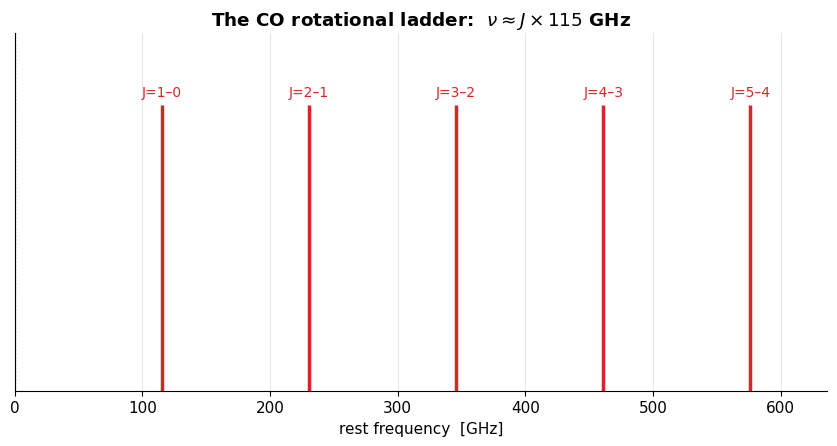

Evenly spaced by 2*B0 = nu(1->0) ~ 115 GHz: the hallmark of a rigid rotor.


In [3]:
# Plot the CO ladder as a "comb" of lines across the mm window.
J_vals = np.arange(1, 6)
nu_ladder = np.array([co_line_frequency(J).to_value(u.GHz) for J in J_vals])

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.vlines(nu_ladder, 0, 1, color="#d62728", lw=2.5)
for J, nu in zip(J_vals, nu_ladder):
    ax.annotate(
        f"J={J}–{J - 1}", xy=(nu, 1.02), ha="center", va="bottom", fontsize=10, color="#d62728"
    )
ax.set_xlim(0, nu_ladder[-1] + 60)
ax.set_ylim(0, 1.25)
ax.set_yticks([])
ax.set_xlabel("rest frequency  [GHz]")
ax.set_title("The CO rotational ladder:  $\\nu \\approx J \\times 115$ GHz")
# Mark the ground state at the origin of the ladder.
ax.axvline(0, color="gray", lw=1, ls=":")
fig.tight_layout()
plt.show()

print("Evenly spaced by 2*B0 = nu(1->0) ~ 115 GHz: the hallmark of a rigid rotor.")

## A molecular cloud in position–velocity

In Chapter 11 we collapsed an HI cube into a **velocity field** to see the Galaxy rotate. The
molecular analogue, and the standard diagnostic for a rotating molecular structure, is the
**position–velocity (PV) diagram**: take a cut across the source (here along the major axis of
a rotating ring of CO) and plot **CO brightness as a function of position and line-of-sight
velocity**.

We simulate a thin **rotating ring/disk** of CO J=1–0 emission. A parcel of gas at projected
offset $x$ along the major axis, orbiting with a flat rotation speed $v_\mathrm{rot}$, shows a
line-of-sight velocity that rises and falls across the source — the classic **rotation
signature**, an "S"-shaped streak in the PV plane. We build the diagram as a pure-numpy 2-D
array (position $\times$ velocity) and display it with `plotting.show_image`, exactly as a
real PV diagram from a CO cube would look.

In [4]:
# --- A toy rotating CO ring, rendered as a position-velocity diagram --------
v_rot = 100.0 * u.km / u.s  # flat rotation speed of the ring
r_ring = 30.0  # ring radius in arcsec (projected)
sigma_line = 4.0 * u.km / u.s  # intrinsic line width of each parcel

# Position axis (offset along the major axis) and velocity axis.
n_pos, n_vel = 121, 121
positions = np.linspace(-50, 50, n_pos)  # arcsec
velocities = np.linspace(-160, 160, n_vel) * (u.km / u.s)  # LSR-like

# Populate the ring with many emitting parcels at azimuths phi.
phi = np.linspace(0, 2 * np.pi, 720, endpoint=False)
x_parcel = r_ring * np.cos(phi)  # projected major-axis offset
# Line-of-sight velocity for circular rotation: v_los = v_rot * cos(phi)
# (maximal where the orbit points along the line of sight, i.e. at the ring edges).
vlos_parcel = v_rot.to_value(u.km / u.s) * np.cos(phi)

# Render onto the (position, velocity) grid with a small Gaussian line width.
pv = np.zeros((n_vel, n_pos))
dpos = positions[1] - positions[0]
sig_v = sigma_line.to_value(u.km / u.s)
vel_val = velocities.to_value(u.km / u.s)
for xp, vp in zip(x_parcel, vlos_parcel):
    ix = int(np.round((xp - positions[0]) / dpos))
    if 0 <= ix < n_pos:
        pv[:, ix] += np.exp(-0.5 * ((vel_val - vp) / sig_v) ** 2)

# Add a touch of realistic noise (seeded).
pv += 0.05 * rng.standard_normal(pv.shape)
pv = np.clip(pv, 0, None)

print(f"PV grid: {pv.shape}  (n_vel, n_pos)")
print(f"position axis : {positions[0]:.0f} ... {positions[-1]:.0f} arcsec")
print(f"velocity axis : {velocities[0]:.0f} ... {velocities[-1]:.0f}")

PV grid: (121, 121)  (n_vel, n_pos)
position axis : -50 ... 50 arcsec
velocity axis : -160 km / s ... 160 km / s


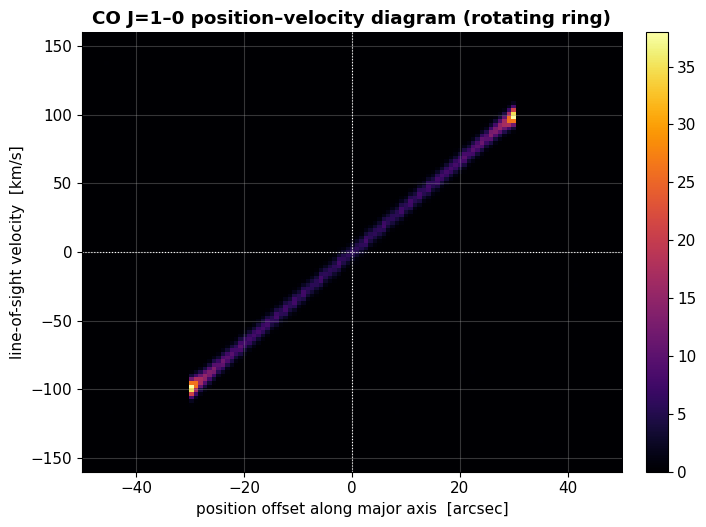

The tilted 'S' streak is the kinematic signature of rotation: one edge of the
ring is redshifted, the other blueshifted -- exactly Chapter 11's velocity field,
now seen edge-on in the position-velocity plane.


In [5]:
fig, ax = plt.subplots(figsize=(7.2, 5.4))
extent = [positions[0], positions[-1], vel_val[0], vel_val[-1]]
plotting.show_image(
    pv,
    ax=ax,
    extent=extent,
    aspect="auto",
    title="CO J=1–0 position–velocity diagram (rotating ring)",
)
ax.set_xlabel("position offset along major axis  [arcsec]")
ax.set_ylabel("line-of-sight velocity  [km/s]")
ax.axhline(0, color="white", lw=0.8, ls=":")
ax.axvline(0, color="white", lw=0.8, ls=":")
fig.tight_layout()
plt.show()

print("The tilted 'S' streak is the kinematic signature of rotation: one edge of the")
print("ring is redshifted, the other blueshifted -- exactly Chapter 11's velocity field,")
print("now seen edge-on in the position-velocity plane.")

### A spectrum at one position

Just as in Chapter 11 we pulled a spectrum through one pixel, here we slice the PV diagram at
a single position to recover the **CO line profile** there. Near the ring edge the line splits
toward the rotation velocity; near the centre it sits close to the systemic velocity.

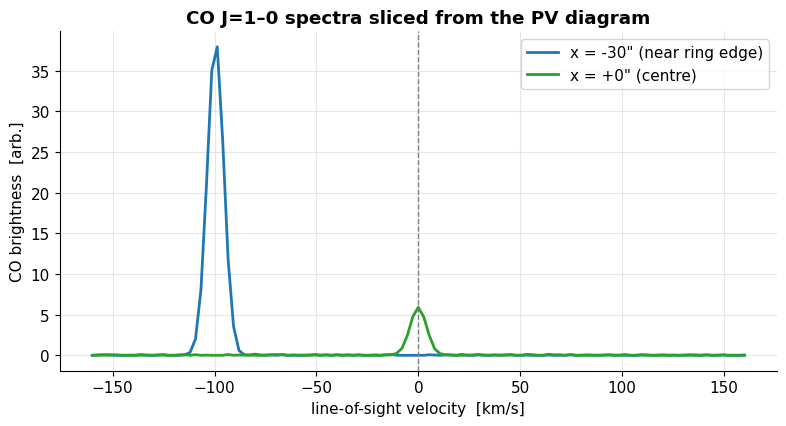

In [6]:
# Take spectra at the ring edge and near the centre.
i_edge = np.argmin(np.abs(positions - (-r_ring)))  # near projected ring edge
i_cen = np.argmin(np.abs(positions - 0.0))  # systemic-ish

fig, ax = plt.subplots(figsize=(8.0, 4.4))
ax.plot(
    vel_val,
    pv[:, i_edge],
    color="#1f77b4",
    lw=2,
    label=f'x = {positions[i_edge]:+.0f}" (near ring edge)',
)
ax.plot(
    vel_val, pv[:, i_cen], color="#2ca02c", lw=2, label=f'x = {positions[i_cen]:+.0f}" (centre)'
)
ax.axvline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("line-of-sight velocity  [km/s]")
ax.set_ylabel("CO brightness  [arb.]")
ax.set_title("CO J=1–0 spectra sliced from the PV diagram")
ax.legend()
fig.tight_layout()
plt.show()

## Masers & weighing a black hole — NGC 4258

Now the headline. The water masers in NGC 4258 lie in a thin disk orbiting the nucleus. The
**high-velocity** masers sit on the disk **midline** — the parts moving directly toward or
away from us — so their full orbital speed shows up along the line of sight:
$v_\mathrm{los} = \sqrt{GM/r}$.

We **simulate the observation**: place masers at a range of radii spanning the masing region
($\sim$0.13–0.26 pc), compute their Keplerian velocities with `keplerian_velocity` for a true
input mass $M = 4\times10^{7}\,M_\odot$, and add a little measurement noise. Then we *recover*
the mass with `maser_central_mass` and compare to the input — reproducing Miyoshi et al.
(1995).

In [7]:
# --- Generate simulated high-velocity masers on the disk midline -----------
M_true = 4.0e7 * u.Msun  # input central mass

# Maser radii spanning the observed masing annulus of NGC 4258.
r_maser = np.linspace(0.13, 0.26, 9) * u.pc

# True Keplerian line-of-sight speeds (midline masers => v_los = v_circ).
v_true = keplerian_velocity(M_true, r_maser)

# Add small, seeded measurement noise (~1% of the speed) to mimic real data.
noise = rng.normal(0.0, 0.01, size=v_true.shape) * v_true
v_obs = v_true + noise

print(f"input central mass : {M_true:.3e}")
print(f"{'r (pc)':>8} {'v_true (km/s)':>14} {'v_obs (km/s)':>13}")
print("-" * 38)
for r, vt, vo in zip(r_maser, v_true, v_obs):
    print(
        f"{r.to_value(u.pc):8.3f} {vt.to_value(u.km / u.s):14.1f} {vo.to_value(u.km / u.s):13.1f}"
    )

input central mass : 4.000e+07 solMass
  r (pc)  v_true (km/s)  v_obs (km/s)
--------------------------------------
   0.130         1150.4        1158.2
   0.146         1084.6        1082.0
   0.163         1028.9        1036.1
   0.179          981.0         982.1
   0.195          939.3         932.0
   0.211          902.4         892.5
   0.228          869.6         856.7
   0.244          840.1         834.6
   0.260          813.4         804.7


In [8]:
# --- Recover the mass from each maser, then averaged --------------------------
# maser_central_mass returns the MEAN enclosed mass when given arrays of masers.
M_fit = maser_central_mass(r_maser, v_obs)
# Per-maser estimates (same M = v^2 r / G applied one maser at a time).
M_individual = u.Quantity([maser_central_mass(r, v) for r, v in zip(r_maser, v_obs)])

print(f"recovered mass (mean of {len(r_maser)} masers) : {M_fit:.3e}")
print(f"input mass                              : {M_true:.3e}")
print(f"fractional error                        : {(M_fit - M_true) / M_true * 100:+.2f} %")
print()
print("Per-maser enclosed-mass estimates (all consistent => single point mass):")
for r, m in zip(r_maser, M_individual):
    print(f"  r = {r.to_value(u.pc):.3f} pc  ->  M = {m.to_value(u.Msun):.3e} Msun")

recovered mass (mean of 9 masers) : 3.966e+07 solMass
input mass                              : 4.000e+07 solMass
fractional error                        : -0.85 %

Per-maser enclosed-mass estimates (all consistent => single point mass):
  r = 0.130 pc  ->  M = 4.054e+07 Msun
  r = 0.146 pc  ->  M = 3.981e+07 Msun
  r = 0.163 pc  ->  M = 4.056e+07 Msun
  r = 0.179 pc  ->  M = 4.008e+07 Msun
  r = 0.195 pc  ->  M = 3.938e+07 Msun
  r = 0.211 pc  ->  M = 3.912e+07 Msun
  r = 0.228 pc  ->  M = 3.882e+07 Msun
  r = 0.244 pc  ->  M = 3.948e+07 Msun
  r = 0.260 pc  ->  M = 3.915e+07 Msun


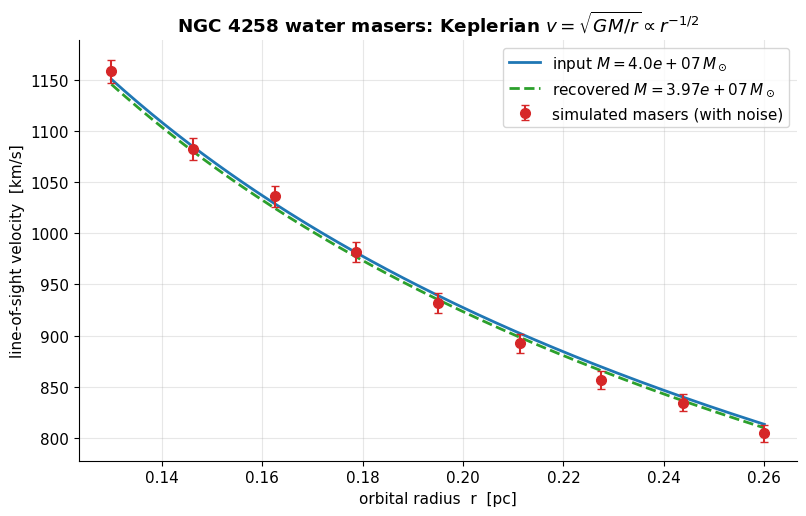

The masers trace a clean r^-1/2 fall-off. Inverting v = sqrt(GM/r) recovers
the input ~4e7 Msun -- a mass so concentrated it must be a supermassive black hole.


In [9]:
# --- Plot v vs r: the Keplerian r^-1/2 fall-off ------------------------------
r_grid = np.linspace(r_maser.min().to_value(u.pc), r_maser.max().to_value(u.pc), 200) * u.pc
v_grid_true = keplerian_velocity(M_true, r_grid)
v_grid_fit = keplerian_velocity(M_fit, r_grid)

fig, ax = plt.subplots(figsize=(8.2, 5.3))
ax.errorbar(
    r_maser.to_value(u.pc),
    v_obs.to_value(u.km / u.s),
    yerr=(0.01 * v_true).to_value(u.km / u.s),
    fmt="o",
    color="#d62728",
    ms=7,
    capsize=3,
    zorder=3,
    label="simulated masers (with noise)",
)
ax.plot(
    r_grid.to_value(u.pc),
    v_grid_true.to_value(u.km / u.s),
    "-",
    color="#1f77b4",
    lw=2,
    label=rf"input $M = {M_true.to_value(u.Msun):.1e}\,M_\odot$",
)
ax.plot(
    r_grid.to_value(u.pc),
    v_grid_fit.to_value(u.km / u.s),
    "--",
    color="#2ca02c",
    lw=2,
    label=rf"recovered $M = {M_fit.to_value(u.Msun):.2e}\,M_\odot$",
)
ax.set_xlabel("orbital radius  r  [pc]")
ax.set_ylabel(r"line-of-sight velocity  [km/s]")
ax.set_title(r"NGC 4258 water masers: Keplerian $v=\sqrt{GM/r}\propto r^{-1/2}$")
ax.legend()
fig.tight_layout()
plt.show()

print("The masers trace a clean r^-1/2 fall-off. Inverting v = sqrt(GM/r) recovers")
print("the input ~4e7 Msun -- a mass so concentrated it must be a supermassive black hole.")

## Try it yourself

1. **Another CO line.** Use `co_line_frequency` to find the CO **J=4–3** and **J=7–6**
   frequencies and their wavelengths. Which atmospheric window do they fall in, and which
   would need ALMA's higher bands? Add them to the ladder plot.

2. **A different molecule.** The rigid-rotor formula works for any linear molecule. CS (carbon
   monosulfide, first found by Penzias et al. 1971) has $B_0 \approx 24.5$ GHz. Use
   `rigid_rotor_frequency(J, 24.5*u.GHz)` to build the CS ladder. Why are CS lines spaced more
   closely than CO's, and what does the smaller $B_0$ tell you about the molecule's moment of
   inertia?

3. **Change the disk rotation.** In the PV-diagram cell, change `v_rot` to 200 km/s and
   `r_ring` to a different value, and re-render. How does the slope/extent of the "S" streak
   respond?

4. **Re-weigh the black hole.** Set `M_true = 1.0e8 * u.Msun` (a heavier black hole), regenerate
   the maser velocities with `keplerian_velocity`, and confirm `maser_central_mass` recovers the
   new mass. By what factor do the maser velocities rise for the same radii?

<details>
<summary>Solution</summary>

The four problems all reuse the chapter's own helpers — `co_line_frequency`,
`rigid_rotor_frequency`, `keplerian_velocity`, `maser_central_mass` — and the toy PV-ring
cell. Worked answers below.

**1. CO J=4–3 and J=7–6.** Since $\nu \approx J\times115.27$ GHz and $\lambda=c/\nu$:

```python
for J in (4, 7):
    nu = co_line_frequency(J)
    lam = (const.c / nu).to(u.mm)
    print(f"CO J={J}-{J-1}: nu = {nu.to_value(u.GHz):.2f} GHz, "
          f"lambda = {lam.to_value(u.mm):.3f} mm")
# CO J=4-3: nu = 461.08 GHz, lambda = 0.650 mm
# CO J=7-6: nu = 806.90 GHz, lambda = 0.372 mm
```

J=4–3 at **461 GHz** ($\lambda=0.65$ mm) sits in the **submillimetre window** reachable from
high, dry sites — **ALMA Band 8** (385–500 GHz). J=7–6 at **807 GHz** ($\lambda=0.37$ mm)
lies near the edge of atmospheric transparency, in **ALMA Band 10** (787–950 GHz), the highest
and most weather-sensitive band. To add them to the ladder plot, extend `J_vals` to
`np.arange(1, 8)` (the ladder stays evenly spaced by $2B_0\approx115$ GHz).

**2. The CS ladder.** CS has $B_0\approx24.5$ GHz, so its lines are spaced by
$2B_0\approx49$ GHz instead of CO's 115 GHz:

```python
B0_CS = 24.5 * u.GHz
for J in range(1, 6):
    nu = rigid_rotor_frequency(J, B0_CS)
    print(f"CS J={J}-{J-1}: nu = {nu.to_value(u.GHz):.1f} GHz")
# CS J=1-0:  49.0   J=2-1:  98.0   J=3-2: 147.0   J=4-3: 196.0   J=5-4: 245.0
```

CS lines are spaced **more closely** ($2B_0$ smaller) because $B_0\propto1/I$, where $I$ is the
moment of inertia: $B_0 = h/(8\pi^2 I)$. A **smaller $B_0$ means a larger $I$** — CS is heavier
and more spread out than CO, $I_{\rm CS}/I_{\rm CO}\approx 57.6/24.5\approx 2.4$. Heavier rotor
$\Rightarrow$ closely packed rotational rungs.

**3. Changing the disk rotation.** In the toy ring, a parcel at projected offset
$x=r_{\rm ring}\cos\phi$ has $v_{\rm los}=v_{\rm rot}\cos\phi$, so eliminating $\phi$ gives a
**linear** locus through the centre,

$$ v_{\rm los} = \frac{v_{\rm rot}}{r_{\rm ring}}\,x. $$

The "S" streak therefore has slope $v_{\rm rot}/r_{\rm ring}$ in the PV plane, runs to a peak
$\pm v_{\rm rot}$ at the ring edges $x=\pm r_{\rm ring}$:

| `v_rot` | `r_ring` | peak $v_{\rm los}$ | slope [(km/s)/arcsec] |
|--------:|---------:|-------------------:|----------------------:|
| 100 | 30 | $\pm100$ | 3.3 |
| 200 | 30 | $\pm200$ | 6.7 |
| 200 | 45 | $\pm200$ | 4.4 |

Doubling `v_rot` to 200 km/s **doubles the velocity extent** (the streak reaches $\pm200$
km/s) and **doubles the slope**; increasing `r_ring` **widens the streak in position** and
**lowers the slope** while keeping the same $\pm v_{\rm rot}$ velocity extent.

**4. Re-weighing the black hole.** Set `M_true = 1.0e8 * u.Msun`, regenerate the midline
velocities, and recover the mass:

```python
M_true = 1.0e8 * u.Msun
r_maser = np.linspace(0.13, 0.26, 9) * u.pc
v_true = keplerian_velocity(M_true, r_maser)      # midline => v_los = v_circ
M_back = maser_central_mass(r_maser, v_true)
print(f"{M_back:.3e}")     # 1.000e+08 solMass  -- recovered exactly (noise-free)
```

The recovered mass matches the input $1.0\times10^{8}\,M_\odot$. Because $v=\sqrt{GM/r}$, at
fixed radius $v\propto\sqrt{M}$, so going from $4\times10^{7}$ to $1\times10^{8}\,M_\odot$
raises every maser velocity by

$$ \sqrt{\frac{1.0\times10^{8}}{4.0\times10^{7}}}=\sqrt{2.5}\approx 1.58\times. $$

(The innermost maser at 0.13 pc jumps from $\sim1150$ km/s to $\sim1819$ km/s.) The mass scales
as $v^2$, so this $1.58\times$ rise in velocity is exactly the $2.5\times$ heavier black hole.

</details>

In [10]:
# Worked starter for exercise 1: extend the CO ladder to J=7.
print("Extended CO ladder:")
for J in range(1, 8):
    nu = co_line_frequency(J)
    lam = (const.c / nu).to(u.mm)
    print(
        f"  J={J}->{J - 1}:  nu = {nu.to_value(u.GHz):8.2f} GHz   "
        f"lambda = {lam.to_value(u.mm):6.3f} mm"
    )

# Worked starter for exercise 4: a heavier black hole.
M_heavy = 1.0e8 * u.Msun
v_heavy = keplerian_velocity(M_heavy, r_maser)
M_back = maser_central_mass(r_maser, v_heavy)
print(f"\nHeavier BH check: input {M_heavy:.2e}  ->  recovered {M_back:.2e}")
print(
    f"velocities scale by sqrt(M_heavy/M_true) = "
    f"{np.sqrt((M_heavy / M_true).to_value(u.dimensionless_unscaled)):.2f}x"
)

Extended CO ladder:
  J=1->0:  nu =   115.27 GHz   lambda =  2.601 mm
  J=2->1:  nu =   230.54 GHz   lambda =  1.300 mm
  J=3->2:  nu =   345.81 GHz   lambda =  0.867 mm
  J=4->3:  nu =   461.08 GHz   lambda =  0.650 mm
  J=5->4:  nu =   576.36 GHz   lambda =  0.520 mm
  J=6->5:  nu =   691.63 GHz   lambda =  0.433 mm
  J=7->6:  nu =   806.90 GHz   lambda =  0.372 mm

Heavier BH check: input 1.00e+08 solMass  ->  recovered 1.00e+08 solMass
velocities scale by sqrt(M_heavy/M_true) = 1.58x


## Recap & what's next

In this chapter we:

- learned why molecules emit **rotational lines** on a **rigid-rotor ladder**, and tabulated
  the **CO** ladder ($\nu \approx J \times 115$ GHz) with `co_line_frequency` and
  `rigid_rotor_frequency` — meeting the standard mm lines J=1–0, 2–1, 3–2 of the **CO tracer
  of molecular gas** (Wilson, Jefferts & Penzias 1970);
- built a **position–velocity diagram** of a rotating CO ring — the molecular analogue of
  Chapter 11's HI velocity field — and sliced CO **spectra** from it;
- met **masers** as compact, inverted-population point probes, and reproduced the **NGC 4258**
  water-maser **black-hole weigh-in** (Miyoshi et al. 1995): simulated Keplerian masers with
  `keplerian_velocity`, recovered $M \approx 4\times10^{7}\,M_\odot$ with
  `maser_central_mass`, and saw the $r^{-1/2}$ fall-off.

**Connecting the threads.** Chapter 11 used **atomic** HI to clock Galactic rotation and
reveal dark matter; here the **molecular** CO line and a maser disk used the *same* kinematic
logic — Doppler velocities versus position/radius — to map a cloud and weigh a black hole.
Where HI gave a flat curve (extended dark mass), the masers gave a Keplerian curve (a single
central point mass).

**What's next.** Real CO and maser data are *images*: cubes made by mm/submm interferometers.
[Chapter 12](12_vla_imaging.ipynb) shows how an interferometer (and CASA) turns visibilities
into the very channel maps and PV diagrams we simulated here. ALMA images CO and dust in
protoplanetary disks and distant galaxies with exactly this machinery.

### References

- **Cheung, Rank, Townes, Thornton & Welch (1968).** *Detection of NH$_3$ Molecules in the
  Interstellar Medium.* Phys. Rev. Lett. 21, 1701.
  [ADS](https://ui.adsabs.harvard.edu/abs/1968PhRvL..21.1701C)
- **Cheung, Rank, Townes, Thornton & Welch (1969).** *Detection of Water in Interstellar
  Regions by its Microwave Radiation.* Nature 221, 626.
  [ADS](https://ui.adsabs.harvard.edu/abs/1969Natur.221..626C)
- **Wilson, Jefferts & Penzias (1970).** *Carbon Monoxide in the Orion Nebula.* ApJ 161, L43.
  [ADS](https://ui.adsabs.harvard.edu/abs/1970ApJ...161L..43W)
- **Miyoshi et al. (1995).** *Evidence for a Black Hole from High Rotation Velocities in a
  Sub-parsec Region of NGC 4258.* Nature 373, 127.
  [ADS](https://ui.adsabs.harvard.edu/abs/1995Natur.373..127M)